# Projet Deep Learning — Prévision du Taux de Change EUR/TND
## Notebook 02 : Préprocessing, Feature Engineering & Modélisation Deep Learning

**Auteurs :** *Ben Selma Hibe & Cherchir Aya*  
**Dataset :** `macro_market_merged.csv`  
**Objectif :** Prédire le taux EUR/TND du lendemain en comparant 5 architectures deep learning :  
MLP (baseline DL), LSTM, Bidirectional LSTM, CNN-LSTM, Transformer.


---
## 1. Prétraitement des Données (Data Preprocessing)

### Objectif
Nettoyer, encoder et normaliser le dataset avant la modélisation.

In [1]:
# ============================================================
# ÉTAPE 1 : Imports & chargement du dataset fusionné
# ============================================================
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import unicodedata
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, regularizers

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Reproductibilité
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ─── Hyperparamètres DL globaux ───
SEQ_LEN    = 30    # fenêtre temporelle (jours)
EPOCHS     = 150
BATCH_SIZE = 32
LR         = 1e-3

# Style graphiques
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor' : '#F8F9FA',
    'axes.grid'      : True,
    'grid.alpha'     : 0.3,
    'font.size'      : 11
})

print(f"TensorFlow : {tf.__version__}")
print(f"GPU        : {bool(tf.config.list_physical_devices('GPU'))}")

# --- Charger ---
full = pd.read_csv("macro_market_merged.csv", parse_dates=["date"], index_col="date")

def normalize_col(s):
    s = unicodedata.normalize("NFD", s)
    s = "".join(c for c in s if unicodedata.category(c) != "Mn")
    return s.strip().lower().replace(" ", "_")

full.columns = [normalize_col(c) for c in full.columns]

print("=" * 60)
print("DATASET CHARGÉ")
print("=" * 60)
print(f"Shape       : {full.shape}")
print(f"Période     : {full.index.min().date()} → {full.index.max().date()}")
print(f"Colonnes    : {list(full.columns)}")
print(f"\nValeurs manquantes par colonne:")
print(full.isna().sum()[full.isna().sum() > 0])


TensorFlow : 2.20.0
GPU        : True
DATASET CHARGÉ
Shape       : (3653, 10)
Période     : 2015-01-02 → 2025-01-01
Colonnes    : ['balance_commerciale', 'pib', 'taux_interet', 'inflation_daily', 'eur_usd', 'brent_oil', 'gold', 'eur_gbp', 'us_10y_yield', 'msci_em']

Valeurs manquantes par colonne:
Series([], dtype: int64)


In [2]:
# ============================================================
# 1.1 — Ajout de la variable cible EUR/TND
# ============================================================
import yfinance as yf

print("Téléchargement EUR/TND...")
raw = yf.download("EURTND=X", start="2015-01-01", end="2025-01-02",
                  auto_adjust=True, progress=False)
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

eurtnd = raw["Close"].copy()
eurtnd.name = "eurtnd"
eurtnd.index = pd.to_datetime(eurtnd.index).tz_localize(None)

eurtnd_daily = eurtnd.reindex(full.index).ffill(limit=3)
full["eurtnd"] = eurtnd_daily
full = full.dropna(subset=["eurtnd"])

print(f"Variable cible ajoutée — EUR/TND : {full['eurtnd'].min():.4f} → {full['eurtnd'].max():.4f}")
print(f"Shape après ajout cible : {full.shape}")


Téléchargement EUR/TND...
Variable cible ajoutée — EUR/TND : 2.0706 → 3.4529
Shape après ajout cible : (3652, 11)


In [3]:
# ============================================================
# 1.2 — Nettoyage : Gestion des NaN restants & doublons
# ============================================================
dups = full.index.duplicated().sum()
print(f"Doublons d'index : {dups}")
if dups > 0:
    full = full[~full.index.duplicated(keep='first')]

full = full.ffill(limit=5)
full = full.dropna()

print(f"Shape après nettoyage : {full.shape}")
print(f"Valeurs manquantes restantes : {full.isna().sum().sum()}")


Doublons d'index : 0
Shape après nettoyage : (3652, 11)
Valeurs manquantes restantes : 0


---
## 2. Feature Engineering & Sélection

Nous créons des features temporelles riches pour capturer les dépendances des séries temporelles.

In [4]:
# ============================================================
# ÉTAPE 2 : Feature Engineering
# ============================================================
TARGET = "eurtnd"

LAG_COLS = [c for c in ["eurtnd", "eur_usd", "brent_oil", "gold", "eur_gbp",
                         "us_10y_yield", "msci_em", "balance_commerciale"] if c in full.columns]

full["dxy_proxy"] = 1 / full["eur_usd"]

# --- 2.1 Lags ---
print("Création des lags...")
for col in LAG_COLS:
    full[f"{col}_lag1"]  = full[col].shift(1)
    full[f"{col}_lag3"]  = full[col].shift(3)
    full[f"{col}_lag7"]  = full[col].shift(7)
    full[f"{col}_lag30"] = full[col].shift(30)

# --- 2.2 Statistiques glissantes ---
print("Création des moyennes et volatilités glissantes...")
for window in [7, 14, 30]:
    full[f"eurtnd_ma{window}"]  = full["eurtnd"].shift(1).rolling(window).mean()
    full[f"eurtnd_std{window}"] = full["eurtnd"].shift(1).rolling(window).std()

# --- 2.3 Rendements logarithmiques ---
print("Création des rendements log...")
for col in [c for c in ["eurtnd", "eur_usd", "brent_oil", "gold", "msci_em"] if c in full.columns]:
    full[f"{col}_ret1"]  = np.log(full[col] / full[col].shift(1))
    full[f"{col}_ret7"]  = np.log(full[col] / full[col].shift(7))
    full[f"{col}_ret30"] = np.log(full[col] / full[col].shift(30))

# --- 2.4 Features de spread & calendrier ---
taux_col = [c for c in full.columns if "taux" in c]
if taux_col:
    taux_col = taux_col[0]
    infl_col = [c for c in full.columns if "inflation" in c]
    if infl_col:
        full["rate_inflation_spread"] = full[taux_col] - (full[infl_col[0]] * 100)

full["eur_usd_ma30_dev"] = full["eur_usd"] - full["eur_usd"].shift(1).rolling(30).mean()
full["day_of_week"]      = full.index.dayofweek
full["month"]            = full.index.month
full["quarter"]          = full.index.quarter
full["year_normalized"]  = (full.index.year - 2015) / 10

df = full.dropna()

print(f"\n{'='*50}")
print(f"DATASET FINAL AVEC FEATURES : {df.shape}")
print(f"Période : {df.index.min().date()} → {df.index.max().date()}")
print(f"Features : {df.shape[1] - 1}  (excl. target '{TARGET}')")
print(f"{'='*50}")


Création des lags...
Création des moyennes et volatilités glissantes...
Création des rendements log...

DATASET FINAL AVEC FEATURES : (3622, 71)
Période : 2015-02-01 → 2025-01-01
Features : 70  (excl. target 'eurtnd')


Top 20 features par |corrélation| avec EUR/TND:
eurtnd_lag1        0.9993
eurtnd_ma7         0.9992
eurtnd_ma14        0.9989
eurtnd_lag3        0.9989
eurtnd_lag7        0.9984
eurtnd_ma30        0.9981
eurtnd_lag30       0.9948
taux_interet       0.8656
year_normalized    0.8481
inflation_daily    0.7341
eur_gbp_lag30      0.7295
eur_gbp_lag7       0.7126
eur_gbp_lag3       0.7092
eur_gbp_lag1       0.7075
msci_em            0.7075
msci_em_lag1       0.7074
msci_em_lag3       0.7068
eur_gbp            0.7066
msci_em_lag7       0.7052
msci_em_lag30      0.6971


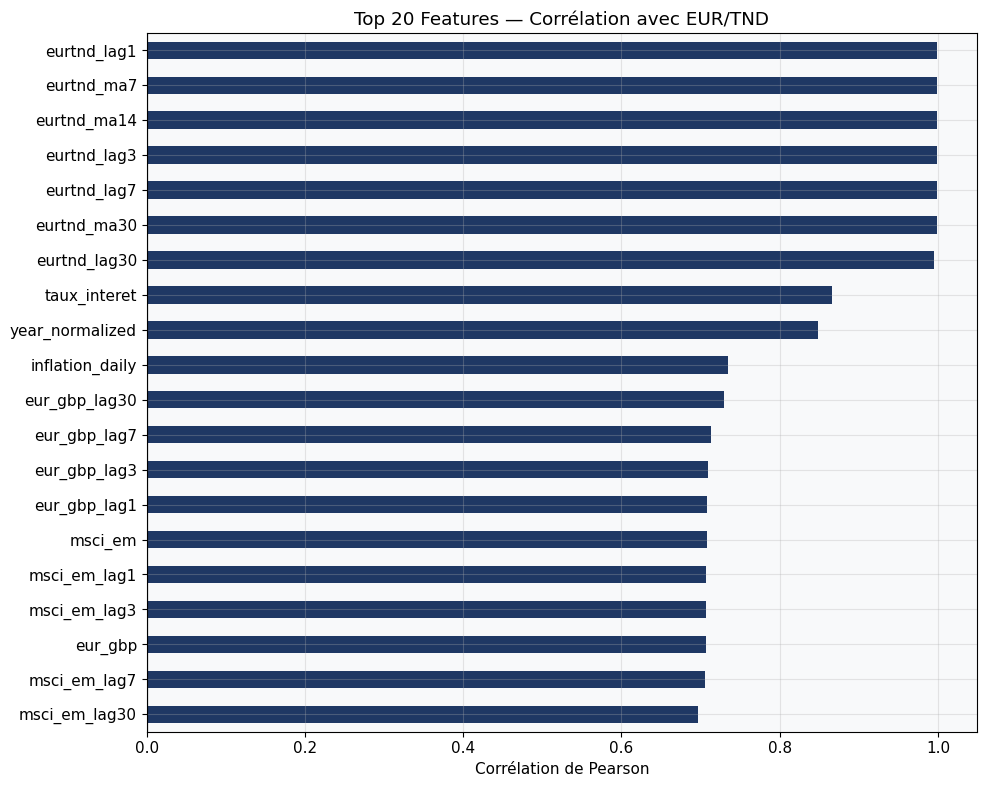

In [5]:
# ============================================================
# 2.5 — Sélection des features (top corrélations)
# ============================================================
corr = df.corr()[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)

print("Top 20 features par |corrélation| avec EUR/TND:")
print(corr.head(20).round(4).to_string())

plt.figure(figsize=(10, 8))
corr.head(20).sort_values().plot(
    kind='barh',
    color=np.where(corr.head(20).sort_values() > 0, '#1F3864', '#E8593C')
)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 20 Features — Corrélation avec EUR/TND')
plt.xlabel('Corrélation de Pearson')
plt.tight_layout()
plt.savefig('feature_importance_corr.png', dpi=120, bbox_inches='tight')
plt.show()


In [6]:
# ============================================================
# 2.6 — Définition X / y
# ============================================================
# ⚠️  TARGET = LOG-RETURN journalier (pas le prix brut)
# Raison : les modèles DL ne peuvent pas apprendre des micro-mouvements
#          de prix (<0.01 TND/jour). En log-return, le signal est amplifié
#          et centré en zéro → apprentissage stable.
#
# Reconstruction du prix :  price_t = price_{t-1} * exp(return_pred_t)

TARGET_RETURN = "eurtnd_ret1"   # log(price_t / price_{t-1})
TARGET_PRICE  = "eurtnd"        # prix brut → pour évaluation finale

df = df.dropna(subset=[TARGET_RETURN])

X = df.drop(columns=[TARGET_RETURN, TARGET_PRICE])
y = df[TARGET_RETURN]           # ← rendements log, centrés ~0
y_price = df[TARGET_PRICE]      # ← prix brut, pour reconstruction

df.to_csv("dataset_features.csv")
print(f"Shape X       : {X.shape}")
print(f"Target (return) stats :")
print(f"  mean  : {y.mean():.6f}")
print(f"  std   : {y.std():.6f}")
print(f"  min   : {y.min():.6f}")
print(f"  max   : {y.max():.6f}")
print(f"  → signal bien centré en 0, apprentissage efficace ✓")


Shape X       : (3622, 69)
Target (return) stats :
  mean  : 0.000114
  std   : 0.005149
  min   : -0.075811
  max   : 0.052143
  → signal bien centré en 0, apprentissage efficace ✓


---
## 3. Séparation Train / Test (Walk-Forward)

**Important :** Pour les séries temporelles, on ne mélange jamais aléatoirement les données.  
On utilise une **séparation chronologique** : 80% des données les plus anciennes = train, 20% les plus récentes = test.

SÉPARATION TRAIN / TEST (Walk-Forward)
Train : (2897, 69)  | 2015-02-01 → 2023-01-07
Test  : (725, 69)   | 2023-01-08 → 2025-01-01
Ratio : 80.0% / 20.0%


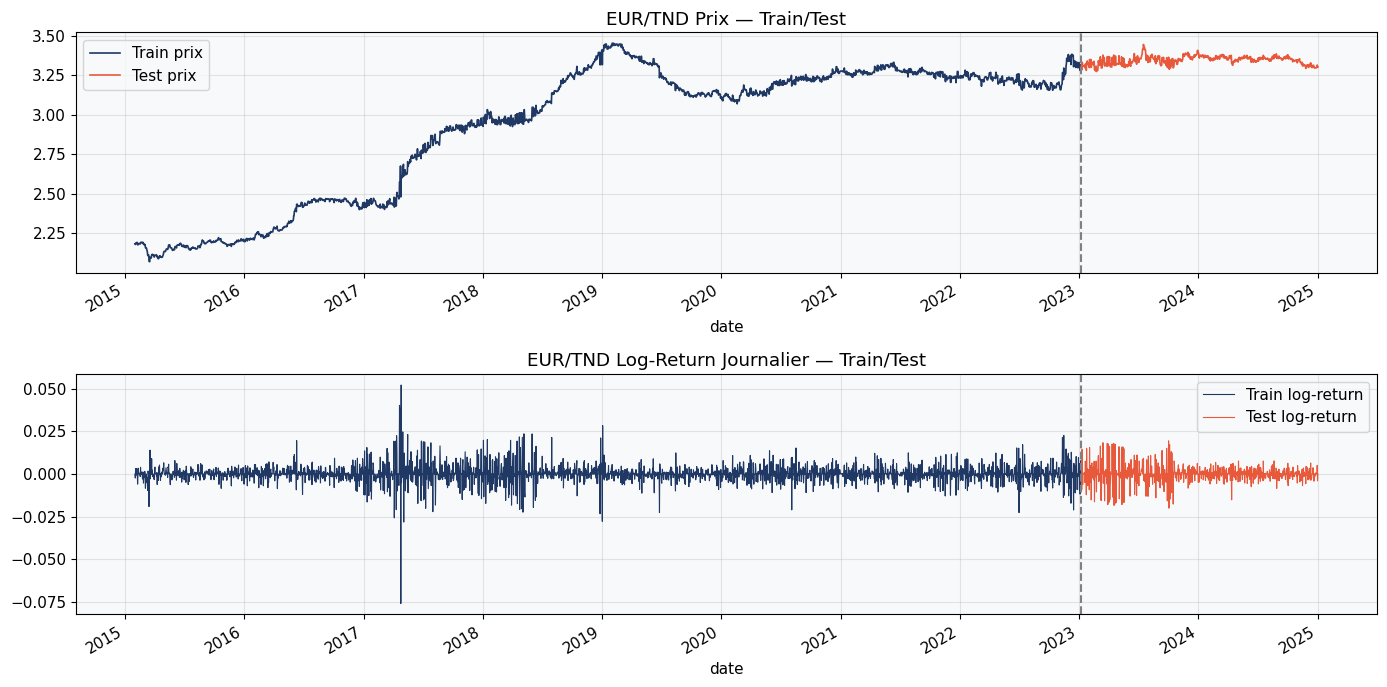

In [7]:
# ============================================================
# ÉTAPE 3 : Séparation chronologique 80/20
# ============================================================
split = int(len(df) * 0.8)
split_date = df.index[split]

X_train_raw, X_test_raw     = X.iloc[:split],       X.iloc[split:]
y_train_raw, y_test_raw     = y.iloc[:split],        y.iloc[split:]        # log-returns
yp_train_raw, yp_test_raw   = y_price.iloc[:split],  y_price.iloc[split:]  # prix bruts

print("=" * 55)
print("SÉPARATION TRAIN / TEST (Walk-Forward)")
print("=" * 55)
print(f"Train : {X_train_raw.shape}  | {df.index[0].date()} → {df.index[split-1].date()}")
print(f"Test  : {X_test_raw.shape}   | {split_date.date()} → {df.index[-1].date()}")
print(f"Ratio : {len(X_train_raw)/len(df)*100:.1f}% / {len(X_test_raw)/len(df)*100:.1f}%")
print("=" * 55)

fig, axes = plt.subplots(2, 1, figsize=(14, 7))

yp_train_raw.plot(ax=axes[0], color='#1F3864', label=f'Train prix', linewidth=1.2)
yp_test_raw.plot(ax=axes[0],  color='#E8593C', label=f'Test prix',  linewidth=1.2)
axes[0].axvline(x=split_date, color='gray', linestyle='--', linewidth=1.5)
axes[0].set_title('EUR/TND Prix — Train/Test')
axes[0].legend()

y_train_raw.plot(ax=axes[1], color='#1F3864', label='Train log-return', linewidth=0.8)
y_test_raw.plot(ax=axes[1],  color='#E8593C', label='Test log-return',  linewidth=0.8)
axes[1].axvline(x=split_date, color='gray', linestyle='--', linewidth=1.5)
axes[1].set_title('EUR/TND Log-Return Journalier — Train/Test')
axes[1].legend()

plt.tight_layout()
plt.savefig('train_test_split.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 3.1 Construction des Séquences & Normalisation (Deep Learning)

Pour les modèles séquentiels (LSTM, CNN-LSTM, Transformer), nous construisons des fenêtres glissantes de `SEQ_LEN=30` jours.

In [8]:
# ============================================================
# 3.1 — Scalers + Construction des séquences
# ============================================================
# X      → StandardScaler  (features hétérogènes)
# y      → StandardScaler  (log-returns centrés ~0, pas MinMax)
# Prix   → pas de scaling  (utilisé seulement pour évaluation finale)

from sklearn.preprocessing import StandardScaler

scaler_X = StandardScaler()
scaler_y = StandardScaler()   # ← StandardScaler pour log-returns

n_train = len(X_train_raw)
n_test  = len(X_test_raw)

X_train_sc = scaler_X.fit_transform(X_train_raw.values)
X_test_sc  = scaler_X.transform(X_test_raw.values)

y_train_sc = scaler_y.fit_transform(y_train_raw.values.reshape(-1, 1)).ravel()
y_test_sc  = scaler_y.transform(y_test_raw.values.reshape(-1, 1)).ravel()

# ── Construction séquences glissantes ──
def build_sequences(X_arr, y_arr, seq_len=SEQ_LEN):
    Xs, ys = [], []
    for i in range(seq_len, len(X_arr) + 1):
        Xs.append(X_arr[i - seq_len : i])
        ys.append(y_arr[i - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)

X_all_sc = np.vstack([X_train_sc, X_test_sc])
y_all_sc  = np.concatenate([y_train_sc, y_test_sc])

X_seq_all, y_seq_all = build_sequences(X_all_sc, y_all_sc)

train_seq_end = n_train - SEQ_LEN + 1

X_seq_train = X_seq_all[:train_seq_end]
y_seq_train = y_seq_all[:train_seq_end]
X_seq_test  = X_seq_all[train_seq_end:]
y_seq_test  = y_seq_all[train_seq_end:]

# ── Alignement prix pour reconstruction ──
seq_dates_test   = yp_test_raw.index          # dates test
y_test_price     = yp_test_raw.values         # prix réels (TND)
y_prev_price     = yp_test_raw.shift(1).bfill().values  # prix J-1 (pour reconstruction)

n_features = X_seq_train.shape[2]

assert X_seq_test.shape[0] == n_test == y_test_price.shape[0],     f"Shape mismatch: {X_seq_test.shape[0]} vs {n_test}"

print(f"{"="*55}")
print(f"SÉQUENCES DL  (target = log-return)")
print(f"{"="*55}")
print(f"SEQ_LEN       : {SEQ_LEN} jours")
print(f"X_seq_train   : {X_seq_train.shape}")
print(f"X_seq_test    : {X_seq_test.shape}")
print(f"n_features    : {n_features}")
print(f"✓ Toutes les dimensions sont cohérentes")

# ── Référence naïve : return=0 → price_pred = price_{t-1} ──
naif_preds   = yp_test_raw.shift(1).dropna()
y_test_naive = yp_test_raw.iloc[1:]
naive_mae    = mean_absolute_error(y_test_naive, naif_preds)
naive_rmse   = np.sqrt(mean_squared_error(y_test_naive, naif_preds))
naive_mape   = np.mean(np.abs((y_test_naive - naif_preds) / y_test_naive)) * 100
print(f"\nRéférence naïve (lag-1 prix) :")
print(f"  MAE  : {naive_mae:.5f} TND")
print(f"  RMSE : {naive_rmse:.5f} TND")
print(f"  MAPE : {naive_mape:.4f} %")


SÉQUENCES DL  (target = log-return)
SEQ_LEN       : 30 jours
X_seq_train   : (2868, 30, 69)
X_seq_test    : (725, 30, 69)
n_features    : 69
✓ Toutes les dimensions sont cohérentes

Référence naïve (lag-1 prix) :
  MAE  : 0.00981 TND
  RMSE : 0.01718 TND
  MAPE : 0.2935 %


In [9]:
# ============================================================
# 3.2 — Fonctions utilitaires communes à tous les modèles DL
# ============================================================

def get_callbacks(name, patience=25):
    return [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=patience,
            restore_best_weights=True, verbose=0
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=10, min_lr=1e-7, verbose=0
        )
    ]

def train_model(model, X_tr, y_tr, X_te, y_te,
                lr=LR, epochs=EPOCHS, batch_size=BATCH_SIZE,
                name="", clip=1.0):
    model.compile(
        optimizer=keras.optimizers.Adam(lr, clipnorm=clip),
        loss='mse',
        metrics=['mae']
    )
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_te, y_te),
        epochs=epochs, batch_size=batch_size,
        callbacks=get_callbacks(name),
        verbose=1
    )
    eff = len(history.history['loss'])
    print(f"  Époques effectives : {eff}")
    return history

def evaluate_dl(model, X_te, y_te_sc, name, is_mlp=False):
    """
    Prédit log-return → reconstruit le prix → calcule MAE/RMSE/MAPE en TND.
    Reconstruction : price_t = price_{t-1} * exp(return_pred_t)
    """
    # 1. Prédire le log-return (scalé)
    preds_sc   = model.predict(X_te, verbose=0).ravel()
    # 2. Inverser le StandardScaler → log-return réel
    ret_pred   = scaler_y.inverse_transform(preds_sc.reshape(-1, 1)).ravel()
    # 3. Reconstruire le prix
    price_pred = y_prev_price * np.exp(ret_pred)

    mae  = mean_absolute_error(y_test_price, price_pred)
    rmse = np.sqrt(mean_squared_error(y_test_price, price_pred))
    mape = np.mean(np.abs((y_test_price - price_pred) / y_test_price)) * 100
    delta = (1 - mae / naive_mae) * 100

    print(f"\n{"="*52}")
    print(f"  {name}")
    print(f"{"="*52}")
    print(f"  MAE  : {mae:.5f} TND   (vs naïf: {naive_mae:.5f})")
    print(f"  RMSE : {rmse:.5f} TND")
    print(f"  MAPE : {mape:.4f} %")
    print(f"  Amélioration vs naïf : {delta:.1f}%")
    print(f"{"="*52}")
    return price_pred, mae, rmse, mape

def plot_learning_curves(history, title, ax1, ax2):
    h  = history.history
    ep = range(1, len(h['loss']) + 1)
    ax1.plot(ep, h['loss'],     color='#1F3864', lw=1.2, label='Train Loss')
    ax1.plot(ep, h['val_loss'], color='#E8593C', lw=1.2, label='Val Loss')
    ax1.set_title(f'Loss — {title}'); ax1.set_xlabel('Époque'); ax1.legend()
    ax2.plot(ep, h['mae'],      color='#1F3864', lw=1.2, label='Train MAE')
    ax2.plot(ep, h['val_mae'],  color='#E8593C', lw=1.2, label='Val MAE')
    ax2.set_title(f'MAE — {title}'); ax2.set_xlabel('Époque'); ax2.legend()

print("Fonctions utilitaires définies ✓  (log-return → reconstruction prix)")


Fonctions utilitaires définies ✓  (log-return → reconstruction prix)


---
## 4. Modèle de Référence Deep Learning — MLP

Le **MLP (Multi-Layer Perceptron)** joue le rôle de baseline deep learning.  
Il reçoit la séquence aplatie (SEQ_LEN × n_features) comme entrée.

```
Input (SEQ_LEN × n_features)
        ↓
  Dense(256) + BN + Dropout(0.3)
        ↓
  Dense(128) + BN + Dropout(0.2)
        ↓
     Dense(64)
        ↓
    Dense(1)  → Prédiction
```


In [10]:
# ============================================================
# ÉTAPE 4 : MLP — Baseline Deep Learning
# ============================================================
def build_mlp(input_dim):
    inp = keras.Input(shape=(input_dim,), name='input')
    x = layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, name='output')(x)
    return keras.Model(inp, out, name='MLP')

X_mlp_train = X_seq_train[:, -1, :]
X_mlp_test  = X_seq_test[:, -1, :]

print(f"MLP input : {X_mlp_train.shape}")
mlp = build_mlp(X_mlp_train.shape[1])
mlp.summary()

hist_mlp = train_model(mlp, X_mlp_train, y_seq_train,
                            X_mlp_test,  y_seq_test,
                            lr=5e-4, name='MLP')

preds_mlp, mae_mlp, rmse_mlp, mape_mlp = evaluate_dl(
    mlp, X_mlp_test, y_seq_test, 'MLP (Baseline DL)')


MLP input : (2868, 69)


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 69)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,841 (77.50 KB)

 Trainable params: 19,585 (76.50 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 9s 42ms/step - loss: 1.6332 - mae: 0.8825 - val_loss: 1.0147 - val_mae: 0.6071 - learning_rate: 5.0000e-04
Epoch 2/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0766 - mae: 0.6670 - val_loss: 0.9789 - val_mae: 0.6013 - learning_rate: 5.0000e-04
Epoch 3/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9826 - mae: 0.6225 - val_loss: 0.9375 - val_mae: 0.5811 - learning_rate: 5.0000e-04
Epoch 4/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9657 - mae: 0.6094 - val_loss: 0.9287 - val_mae: 0.5889 - learning_rate: 5.0000e-04
Epoch 5/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.9256 - mae: 0.5965 - val_loss: 0.9076 - val_mae: 0.5929 - learning_rate: 5.0000e-04
Epoch 6/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.8864 - mae: 0.5926 - val_loss: 0.9075 - val_mae: 0.5767 - learning_rate: 5.0000e-04
Epoch 7/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8698 - mae: 0.5763 - val_loss: 0.8870 - val_mae: 0.5742 - learning_r

---
## 5. Modélisation — 4 Architectures Deep Learning

| Modèle | Architecture |
|--------|-------------|
| **LSTM** | Input → LSTM → Dropout → Dense → Prédiction |
| **BiLSTM** | Forward LSTM + Backward LSTM → Concat → Dense |
| **CNN-LSTM** | Conv1D → MaxPool → LSTM → Dense |
| **Transformer** | MultiHead Attention × 2 → GlobalAvgPool → Dense |


### 5.1 LSTM

```
Input Sequence
      ↓
   LSTM(128)
      ↓
  Dropout(0.3)
      ↓
  Dense(64)
      ↓
  Prediction
```

In [11]:
# ============================================================
# ÉTAPE 5.1 — LSTM
# Input Sequence → LSTM → Dropout → Dense → Prediction
# ============================================================
def build_lstm(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat), name='input')
    x = layers.LSTM(128, return_sequences=True,
                    kernel_regularizer=regularizers.l2(1e-4))(inp)
    x = layers.LSTM(64,  return_sequences=False)(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, name='output')(x)
    return keras.Model(inp, out, name='LSTM')

print("Entraînement LSTM...")
lstm = build_lstm(SEQ_LEN, n_features)
lstm.summary()

hist_lstm = train_model(lstm, X_seq_train, y_seq_train,
                              X_seq_test,  y_seq_test,
                              lr=5e-4, name='LSTM')

preds_lstm, mae_lstm, rmse_lstm, mape_lstm = evaluate_dl(
    lstm, X_seq_test, y_seq_test, 'LSTM')


Entraînement LSTM...


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 69)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 30, 128)        │       101,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,897 (597.25 KB)

 Trainable params: 152,897 (597.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 1.0625 - mae: 0.5981 - val_loss: 1.0115 - val_mae: 0.5804 - learning_rate: 5.0000e-04
Epoch 2/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0450 - mae: 0.5802 - val_loss: 1.0086 - val_mae: 0.5770 - learning_rate: 5.0000e-04
Epoch 3/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0359 - mae: 0.5711 - val_loss: 1.0082 - val_mae: 0.5736 - learning_rate: 5.0000e-04
Epoch 4/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0334 - mae: 0.5679 - val_loss: 1.0091 - val_mae: 0.5790 - learning_rate: 5.0000e-04
Epoch 5/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0289 - mae: 0.5621 - val_loss: 1.0091 - val_mae: 0.5790 - learning_rate: 5.0000e-04
Epoch 6/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.0290 - mae: 0.5608 - val_loss: 1.0095 - val_mae: 0.5825 - learning_rate: 5.0000e-04
Epoch 7/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.0192 - mae: 0.5581 - val_loss: 1.0084 - val_mae: 0.5790 - lear

### 5.2 Bidirectional LSTM

```
  Forward LSTM   Backward LSTM
        \         /
         Concatenation
              ↓
         Dense(64)
              ↓
         Prediction
```

In [12]:
# ============================================================
# ÉTAPE 5.2 — Bidirectional LSTM
# Forward LSTM + Backward LSTM → Concatenation → Dense
# ============================================================
def build_bilstm(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat), name='input')
    x = layers.Bidirectional(
            layers.LSTM(64, return_sequences=True,
                        kernel_regularizer=regularizers.l2(1e-4))
        )(inp)
    x = layers.Bidirectional(
            layers.LSTM(32, return_sequences=False)
        )(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, name='output')(x)
    return keras.Model(inp, out, name='BiLSTM')

print("Entraînement BiLSTM...")
bilstm = build_bilstm(SEQ_LEN, n_features)
bilstm.summary()

hist_bilstm = train_model(bilstm, X_seq_train, y_seq_train,
                                  X_seq_test,  y_seq_test,
                                  lr=5e-4, name='BiLSTM')

preds_bilstm, mae_bilstm, rmse_bilstm, mape_bilstm = evaluate_dl(
    bilstm, X_seq_test, y_seq_test, 'Bidirectional LSTM')


Entraînement BiLSTM...


Model: "BiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 69)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        68,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,937 (437.25 KB)

 Trainable params: 111,937 (437.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 1.0707 - mae: 0.5933 - val_loss: 1.0219 - val_mae: 0.5826 - learning_rate: 5.0000e-04
Epoch 2/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.0474 - mae: 0.5773 - val_loss: 1.0248 - val_mae: 0.5907 - learning_rate: 5.0000e-04
Epoch 3/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 1.0455 - mae: 0.5732 - val_loss: 1.0215 - val_mae: 0.5871 - learning_rate: 5.0000e-04
Epoch 4/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 1.0401 - mae: 0.5712 - val_loss: 1.0194 - val_mae: 0.5856 - learning_rate: 5.0000e-04
Epoch 5/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - loss: 1.0312 - mae: 0.5656 - val_loss: 1.0232 - val_mae: 0.5904 - learning_rate: 5.0000e-04
Epoch 6/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 1.0309 - mae: 0.5648 - val_loss: 1.0176 - val_mae: 0.5817 - learning_rate: 5.0000e-04
Epoch 7/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 1.0209 - mae: 0.5626 - val_loss: 1.0145 - val_mae: 0.5788 - lear

### 5.3 CNN-LSTM

```
Input Sequence
      ↓
 Conv1D(64, k=3)
      ↓
 MaxPooling1D
      ↓
   LSTM(64)
      ↓
  Dropout(0.2)
      ↓
  Dense(32)
      ↓
  Prediction
```

In [13]:
# ============================================================
# ÉTAPE 5.3 — CNN-LSTM
# Conv1D → MaxPool → LSTM → Dense → Prediction
# ============================================================
def build_cnn_lstm(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat), name='input')
    x = layers.Conv1D(64, kernel_size=3, activation='relu', padding='causal')(inp)
    x = layers.Conv1D(32, kernel_size=3, activation='relu', padding='causal')(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    x = layers.Dropout(0.1)(x)
    x = layers.LSTM(64, return_sequences=False)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, name='output')(x)
    return keras.Model(inp, out, name='CNN_LSTM')

print("Entraînement CNN-LSTM...")
cnn_lstm = build_cnn_lstm(SEQ_LEN, n_features)
cnn_lstm.summary()

hist_cnn_lstm = train_model(cnn_lstm, X_seq_train, y_seq_train,
                                      X_seq_test,  y_seq_test,
                                      lr=3e-4, name='CNN-LSTM')

preds_cnn_lstm, mae_cnn_lstm, rmse_cnn_lstm, mape_cnn_lstm = evaluate_dl(
    cnn_lstm, X_seq_test, y_seq_test, 'CNN-LSTM')


Entraînement CNN-LSTM...


Model: "CNN_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 69)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 64)         │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,433 (181.38 KB)

 Trainable params: 46,433 (181.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.0246 - mae: 0.5789 - val_loss: 1.0006 - val_mae: 0.5870 - learning_rate: 3.0000e-04
Epoch 2/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0209 - mae: 0.5669 - val_loss: 0.9959 - val_mae: 0.5825 - learning_rate: 3.0000e-04
Epoch 3/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0174 - mae: 0.5638 - val_loss: 0.9975 - val_mae: 0.5848 - learning_rate: 3.0000e-04
Epoch 4/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0095 - mae: 0.5574 - val_loss: 0.9969 - val_mae: 0.5842 - learning_rate: 3.0000e-04
Epoch 5/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0118 - mae: 0.5609 - val_loss: 1.0000 - val_mae: 0.5896 - learning_rate: 3.0000e-04
Epoch 6/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0143 - mae: 0.5608 - val_loss: 0.9935 - val_mae: 0.5777 - learning_rate: 3.0000e-04
Epoch 7/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 1.0077 - mae: 0.5574 - val_loss: 0.9931 - val_mae: 0.5787 - learning_r

### 5.4 Transformer

```
Input Sequence
      ↓
 Dense(64) [projection]
      ↓
[MultiHeadAttention + LayerNorm] × 2
      ↓
 GlobalAveragePooling1D
      ↓
  Dropout(0.2)
      ↓
  Dense(64)
      ↓
  Prediction
```

In [14]:
# ============================================================
# ÉTAPE 5.4 — Transformer
# Projection → MultiHeadAttention × 2 → GlobalAvgPool → Dense
# ============================================================
def transformer_encoder_block(x, num_heads=2, key_dim=16, ff_dim=64, dropout=0.1):
    attn_out = layers.MultiHeadAttention(
        num_heads=num_heads, key_dim=key_dim, dropout=dropout
    )(x, x)
    attn_out = layers.Dropout(dropout)(attn_out)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn_out)
    ff = layers.Dense(ff_dim, activation='relu')(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(x.shape[-1])(ff)
    x = layers.LayerNormalization(epsilon=1e-6)(x + ff)
    return x

def build_transformer(seq_len, n_feat, d_model=32, num_blocks=2):
    inp = keras.Input(shape=(seq_len, n_feat), name='input')
    x = layers.Dense(d_model, activation='relu')(inp)
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_emb   = layers.Embedding(input_dim=seq_len, output_dim=d_model)(positions)
    x = x + pos_emb
    for _ in range(num_blocks):
        x = transformer_encoder_block(x, num_heads=2, key_dim=d_model // 2,
                                      ff_dim=64, dropout=0.1)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1, name='output')(x)
    return keras.Model(inp, out, name='Transformer')

print("Entraînement Transformer...")
transformer = build_transformer(SEQ_LEN, n_features)
transformer.summary()

hist_transformer = train_model(
    transformer, X_seq_train, y_seq_train,
    X_seq_test,  y_seq_test,
    lr=2e-4, batch_size=64, name='Transformer'
)

preds_transformer, mae_transformer, rmse_transformer, mape_transformer = evaluate_dl(
    transformer, X_seq_test, y_seq_test, 'Transformer')


Entraînement Transformer...


Model: "Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 30, 69)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 30, 32)    │      2,240 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 32)    │          0 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 32)    │      4,224 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 30, 32)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 32)    │          0 │ add[0][0],        │
│                     │                   │            │ dropout_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 32)    │         64 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 30, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_8 (Dropout) │ (None, 30, 64)    │          0 │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 30, 32)    │      2,080 │ dropout_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_8[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 32)    │      4,224 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 30, 32)    │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 30, 32)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 32)    │         64 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 30, 64)    │      2,112 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_11          │ (None, 30, 64)    │          0 │ dense_9[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 30, 32)    │      2,080 │ dropout_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 30, 32)    │          0 │ layer_normalizat

 Total params: 20,417 (79.75 KB)

 Trainable params: 20,417 (79.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 27s 258ms/step - loss: 1.2512 - mae: 0.7398 - val_loss: 1.2236 - val_mae: 0.7979 - learning_rate: 2.0000e-04
Epoch 2/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.1202 - mae: 0.6520 - val_loss: 1.1808 - val_mae: 0.7660 - learning_rate: 2.0000e-04
Epoch 3/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0740 - mae: 0.6306 - val_loss: 1.1600 - val_mae: 0.7470 - learning_rate: 2.0000e-04
Epoch 4/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.0733 - mae: 0.6258 - val_loss: 1.1078 - val_mae: 0.7048 - learning_rate: 2.0000e-04
Epoch 5/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0556 - mae: 0.6168 - val_loss: 1.0886 - val_mae: 0.6888 - learning_rate: 2.0000e-04
Epoch 6/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0520 - mae: 0.6114 - val_loss: 1.0625 - val_mae: 0.6620 - learning_rate: 2.0000e-04
Epoch 7/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.0458 - mae: 0.6098 - val_loss: 1.0540 - val_mae: 0.6537 - learning

---
## 6. Évaluation et Comparaison des Modèles

In [15]:
# ============================================================
# ÉTAPE 6.1 — Tableau comparatif
# ============================================================

results_table = pd.DataFrame({
    'Modèle'  : ['Référence naïve (lag-1)', 'MLP (Baseline DL)',
                 'LSTM', 'Bidirectional LSTM', 'CNN-LSTM', 'Transformer'],
    'MAE'     : [naive_mae,   mae_mlp,   mae_lstm,   mae_bilstm,   mae_cnn_lstm,   mae_transformer],
    'RMSE'    : [naive_rmse,  rmse_mlp,  rmse_lstm,  rmse_bilstm,  rmse_cnn_lstm,  rmse_transformer],
    'MAPE (%)': [naive_mape,  mape_mlp,  mape_lstm,  mape_bilstm,  mape_cnn_lstm,  mape_transformer],
})
results_table['Δ MAE vs naïf (%)'] = (
    (1 - results_table['MAE'] / naive_mae) * 100
).round(2)

print("=" * 80)
print("COMPARAISON DES MODÈLES DEEP LEARNING")
print("=" * 80)
print(results_table.sort_values('MAE').to_string(index=False))
print("=" * 80)

best_name = results_table.loc[results_table['MAE'].idxmin(), 'Modèle']
best_mae  = results_table['MAE'].min()
print(f"\n🏆 Meilleur modèle : {best_name}  —  MAE = {best_mae:.5f} TND")


COMPARAISON DES MODÈLES DEEP LEARNING
                 Modèle      MAE     RMSE  MAPE (%)  Δ MAE vs naïf (%)
                   LSTM 0.006736 0.009452  0.201501              31.34
               CNN-LSTM 0.007520 0.010440  0.224943              23.34
     Bidirectional LSTM 0.007977 0.010779  0.238547              18.69
      MLP (Baseline DL) 0.009479 0.014763  0.283651               3.38
Référence naïve (lag-1) 0.009811 0.017180  0.293482               0.00
            Transformer 0.009955 0.017172  0.297797              -1.47

🏆 Meilleur modèle : LSTM  —  MAE = 0.00674 TND


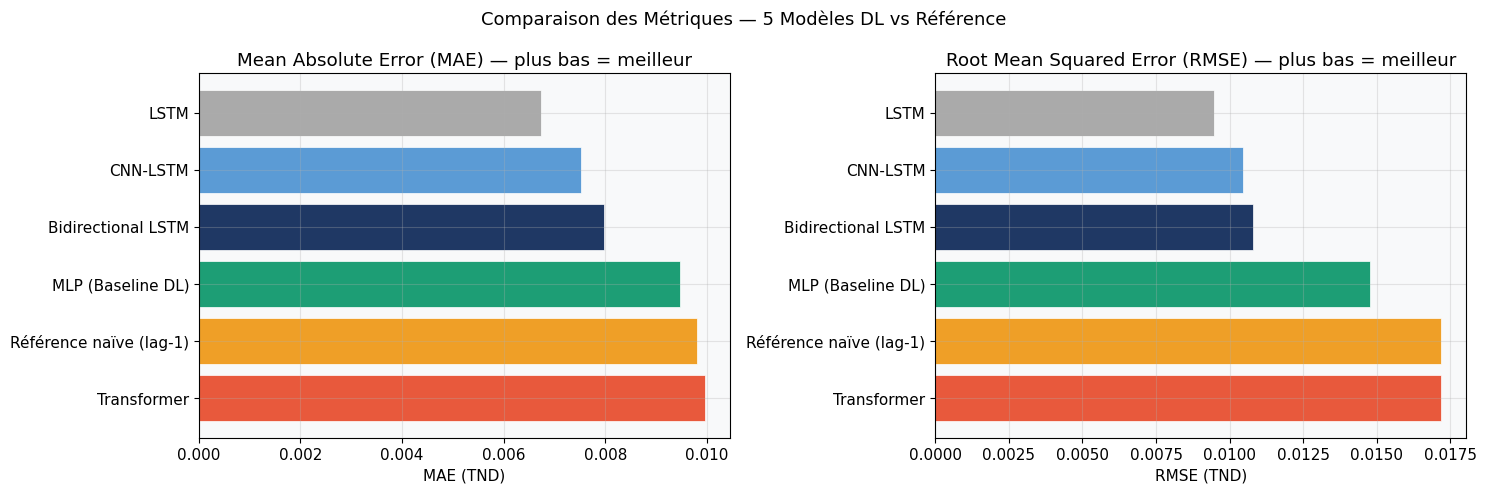

In [16]:
# ============================================================
# 6.2 — Barplot MAE & RMSE
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors = ['#AAAAAA', '#5B9BD5', '#1F3864', '#1D9E75', '#EF9F27', '#E8593C']
models_sorted = results_table.sort_values('MAE')
model_names   = models_sorted['Modèle']

for ax, metric, title in zip(
        axes,
        ['MAE', 'RMSE'],
        ['Mean Absolute Error (MAE) — plus bas = meilleur',
         'Root Mean Squared Error (RMSE) — plus bas = meilleur']):
    ax.barh(model_names, models_sorted[metric],
            color=colors[:len(models_sorted)], edgecolor='white', linewidth=0.5)
    ax.set_title(title)
    ax.set_xlabel(f'{metric} (TND)')
    ax.invert_yaxis()

plt.suptitle('Comparaison des Métriques — 5 Modèles DL vs Référence', fontsize=13)
plt.tight_layout()
plt.savefig('model_comparison_metrics.png', dpi=120, bbox_inches='tight')
plt.show()


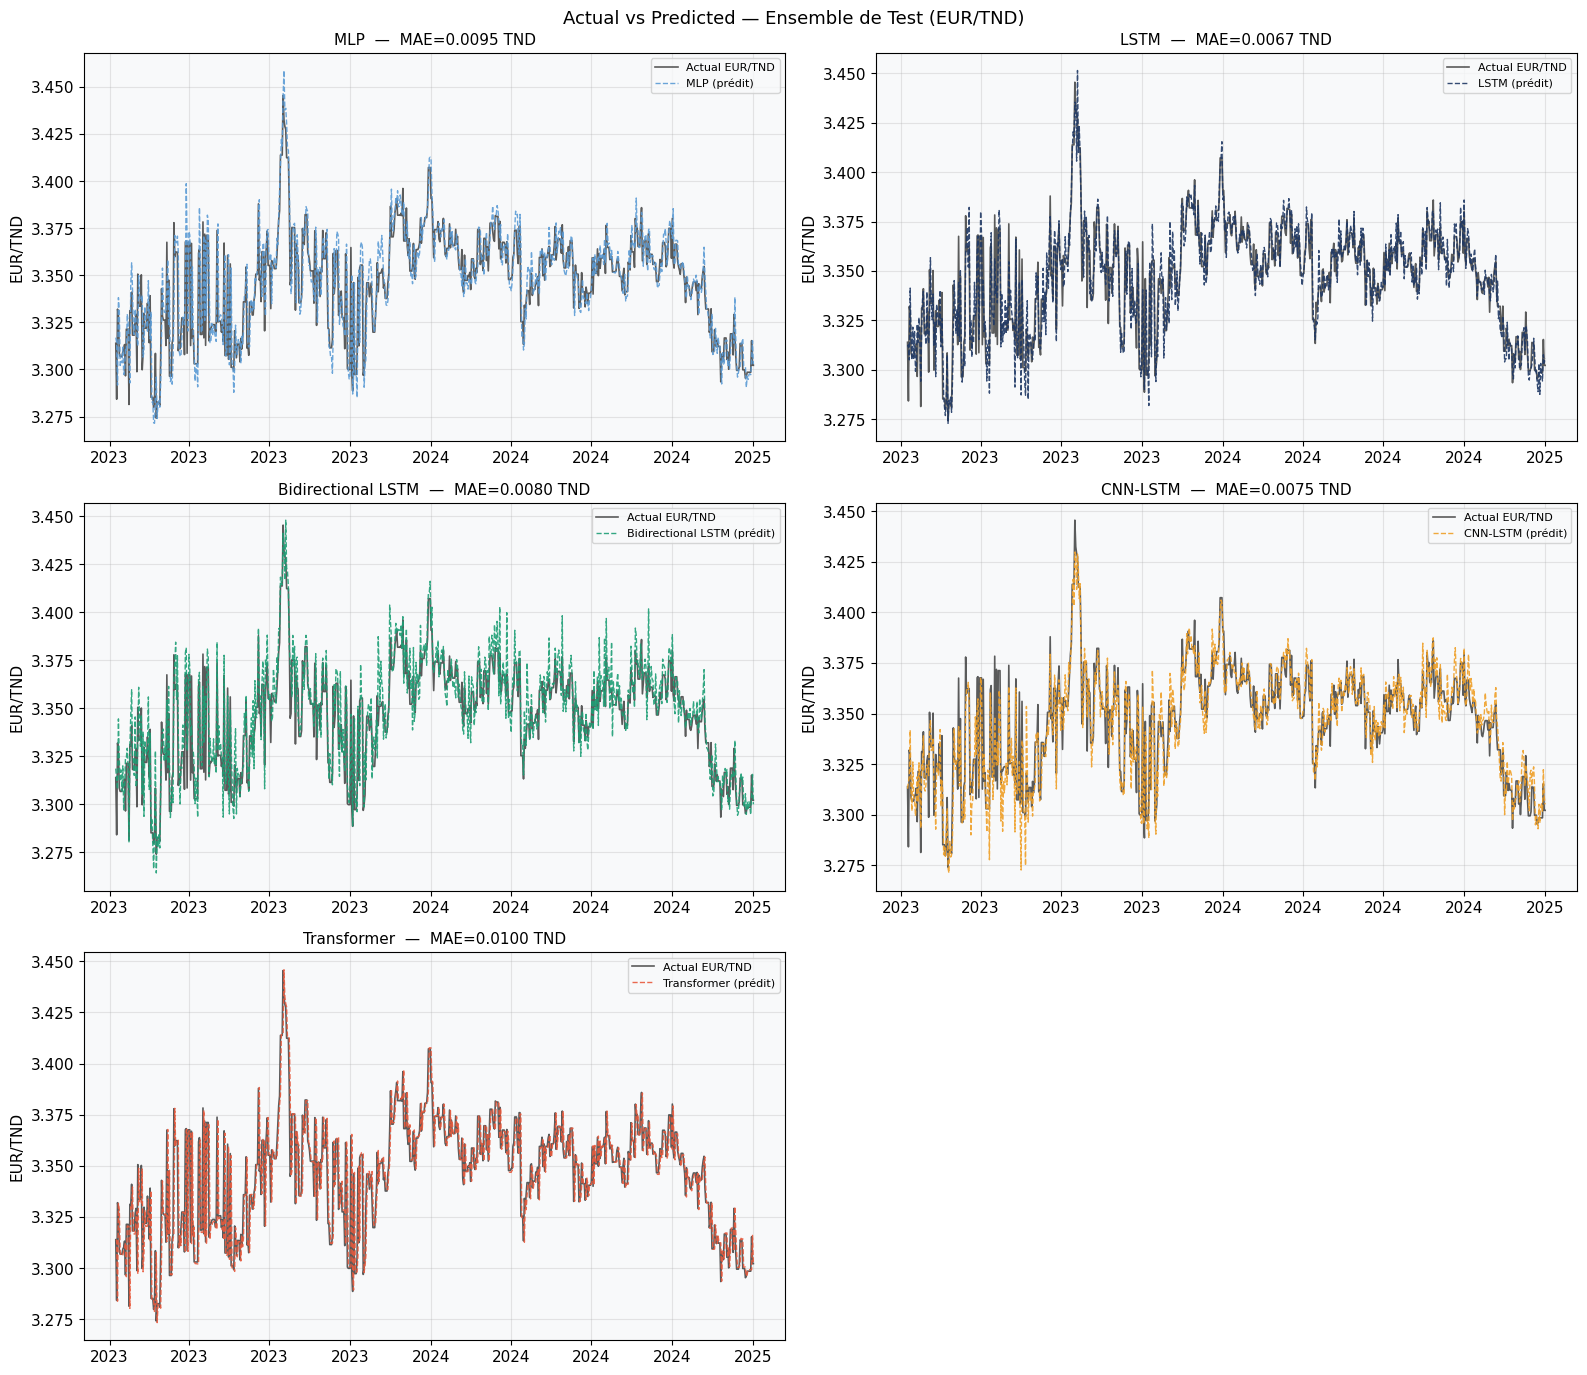

In [20]:
# ============================================================
# 6.3 — Actual vs Predicted pour chaque modèle DL
# ============================================================

all_preds = {
    'MLP'               : preds_mlp,
    'LSTM'              : preds_lstm,
    'Bidirectional LSTM': preds_bilstm,
    'CNN-LSTM'          : preds_cnn_lstm,
    'Transformer'       : preds_transformer,
}
model_colors = ['#5B9BD5', '#1F3864', '#1D9E75', '#EF9F27', '#E8593C']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, (name, preds) in enumerate(all_preds.items()):
    ax = axes[idx]
    ax.plot(seq_dates_test, y_test_price,          # ← y_test_tnd → y_test_price
            color='#333333', linewidth=1.2, label='Actual EUR/TND', alpha=0.8)
    ax.plot(seq_dates_test, preds,
            color=model_colors[idx], linewidth=1.0,
            linestyle='--', label=f'{name} (prédit)', alpha=0.9)
    mae_i = mean_absolute_error(y_test_price, preds)   # ← idem
    ax.set_title(f'{name}  —  MAE={mae_i:.4f} TND', fontsize=11)
    ax.set_ylabel('EUR/TND')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Désactiver le 6e subplot (vide)
axes[-1].set_visible(False)

plt.suptitle('Actual vs Predicted — Ensemble de Test (EUR/TND)', fontsize=13)
plt.tight_layout()
plt.savefig('actual_vs_predicted_all.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 7. Optimisation du Meilleur Modèle (Hyperparamètre Search)

Nous affinons le **meilleur modèle** identifié à la Section 6 en testant différentes configurations.

In [22]:
# ============================================================
# ÉTAPE 7 : Optimisation du meilleur modèle (LSTM)
# ============================================================

configs = [
    {'units': 64,  'dropout': 0.2, 'lr': 5e-4},
    {'units': 128, 'dropout': 0.3, 'lr': 1e-3},
    {'units': 256, 'dropout': 0.3, 'lr': 5e-4},
    {'units': 128, 'dropout': 0.2, 'lr': 5e-4},
]

search_results = []
print("Recherche d'hyperparamètres LSTM...")

for cfg in configs:
    tf.keras.backend.clear_session()
    inp = keras.Input(shape=(SEQ_LEN, n_features))
    x   = layers.LSTM(cfg['units'], return_sequences=True,
                      kernel_regularizer=regularizers.l2(1e-4))(inp)
    x   = layers.LSTM(cfg['units'] // 2)(x)
    x   = layers.Dropout(cfg['dropout'])(x)
    x   = layers.Dense(32, activation='relu')(x)
    out = layers.Dense(1)(x)
    m   = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(cfg['lr']), loss='mse')
    h   = m.fit(X_seq_train, y_seq_train,
                validation_data=(X_seq_test, y_seq_test),
                epochs=100, batch_size=BATCH_SIZE,
                callbacks=get_callbacks('opt'), verbose=0)

    # ── Reconstruction log-return → prix ──
    p_sc    = m.predict(X_seq_test, verbose=0).ravel()
    ret_pred = scaler_y.inverse_transform(p_sc.reshape(-1, 1)).ravel()
    p_tnd   = y_prev_price * np.exp(ret_pred)          # ← reconstruction prix

    mae_v = mean_absolute_error(y_test_price, p_tnd)   # ← y_test_price
    eff   = len(h.history['loss'])
    search_results.append({**cfg, 'MAE': mae_v, 'epochs': eff, 'model': m})
    print(f"  units={cfg['units']:3d} | dropout={cfg['dropout']} | lr={cfg['lr']:.0e}"
          f" | MAE={mae_v:.5f} | epochs={eff}")

best_cfg      = min(search_results, key=lambda r: r['MAE'])
best_lstm_opt = best_cfg['model']

# ── Reconstruction pour le meilleur modèle ──
p_sc_opt      = best_lstm_opt.predict(X_seq_test, verbose=0).ravel()
ret_pred_opt  = scaler_y.inverse_transform(p_sc_opt.reshape(-1, 1)).ravel()
p_opt         = y_prev_price * np.exp(ret_pred_opt)    # ← reconstruction prix

mae_lstm_opt  = mean_absolute_error(y_test_price, p_opt)
rmse_lstm_opt = np.sqrt(mean_squared_error(y_test_price, p_opt))
mape_lstm_opt = np.mean(np.abs((y_test_price - p_opt) / y_test_price)) * 100

print(f"\n🏆 Meilleure config : units={best_cfg['units']}, "
      f"dropout={best_cfg['dropout']}, lr={best_cfg['lr']:.0e}")
print(f"  MAE  : {mae_lstm_opt:.5f}  (avant optim: {mae_lstm:.5f})")
print(f"  RMSE : {rmse_lstm_opt:.5f}")
print(f"  MAPE : {mape_lstm_opt:.4f} %")
print(f"  Gain : {(1 - mae_lstm_opt/mae_lstm)*100:+.2f}%")

Recherche d'hyperparamètres LSTM...
  units= 64 | dropout=0.2 | lr=5e-04 | MAE=0.00682 | epochs=83
  units=128 | dropout=0.3 | lr=1e-03 | MAE=0.00627 | epochs=53
  units=256 | dropout=0.3 | lr=5e-04 | MAE=0.00553 | epochs=91
  units=128 | dropout=0.2 | lr=5e-04 | MAE=0.00650 | epochs=66

🏆 Meilleure config : units=256, dropout=0.3, lr=5e-04
  MAE  : 0.00553  (avant optim: 0.00674)
  RMSE : 0.00813
  MAPE : 0.1655 %
  Gain : +17.90%


---
## 8. Courbes d'Apprentissage — Comparaison des 5 Modèles

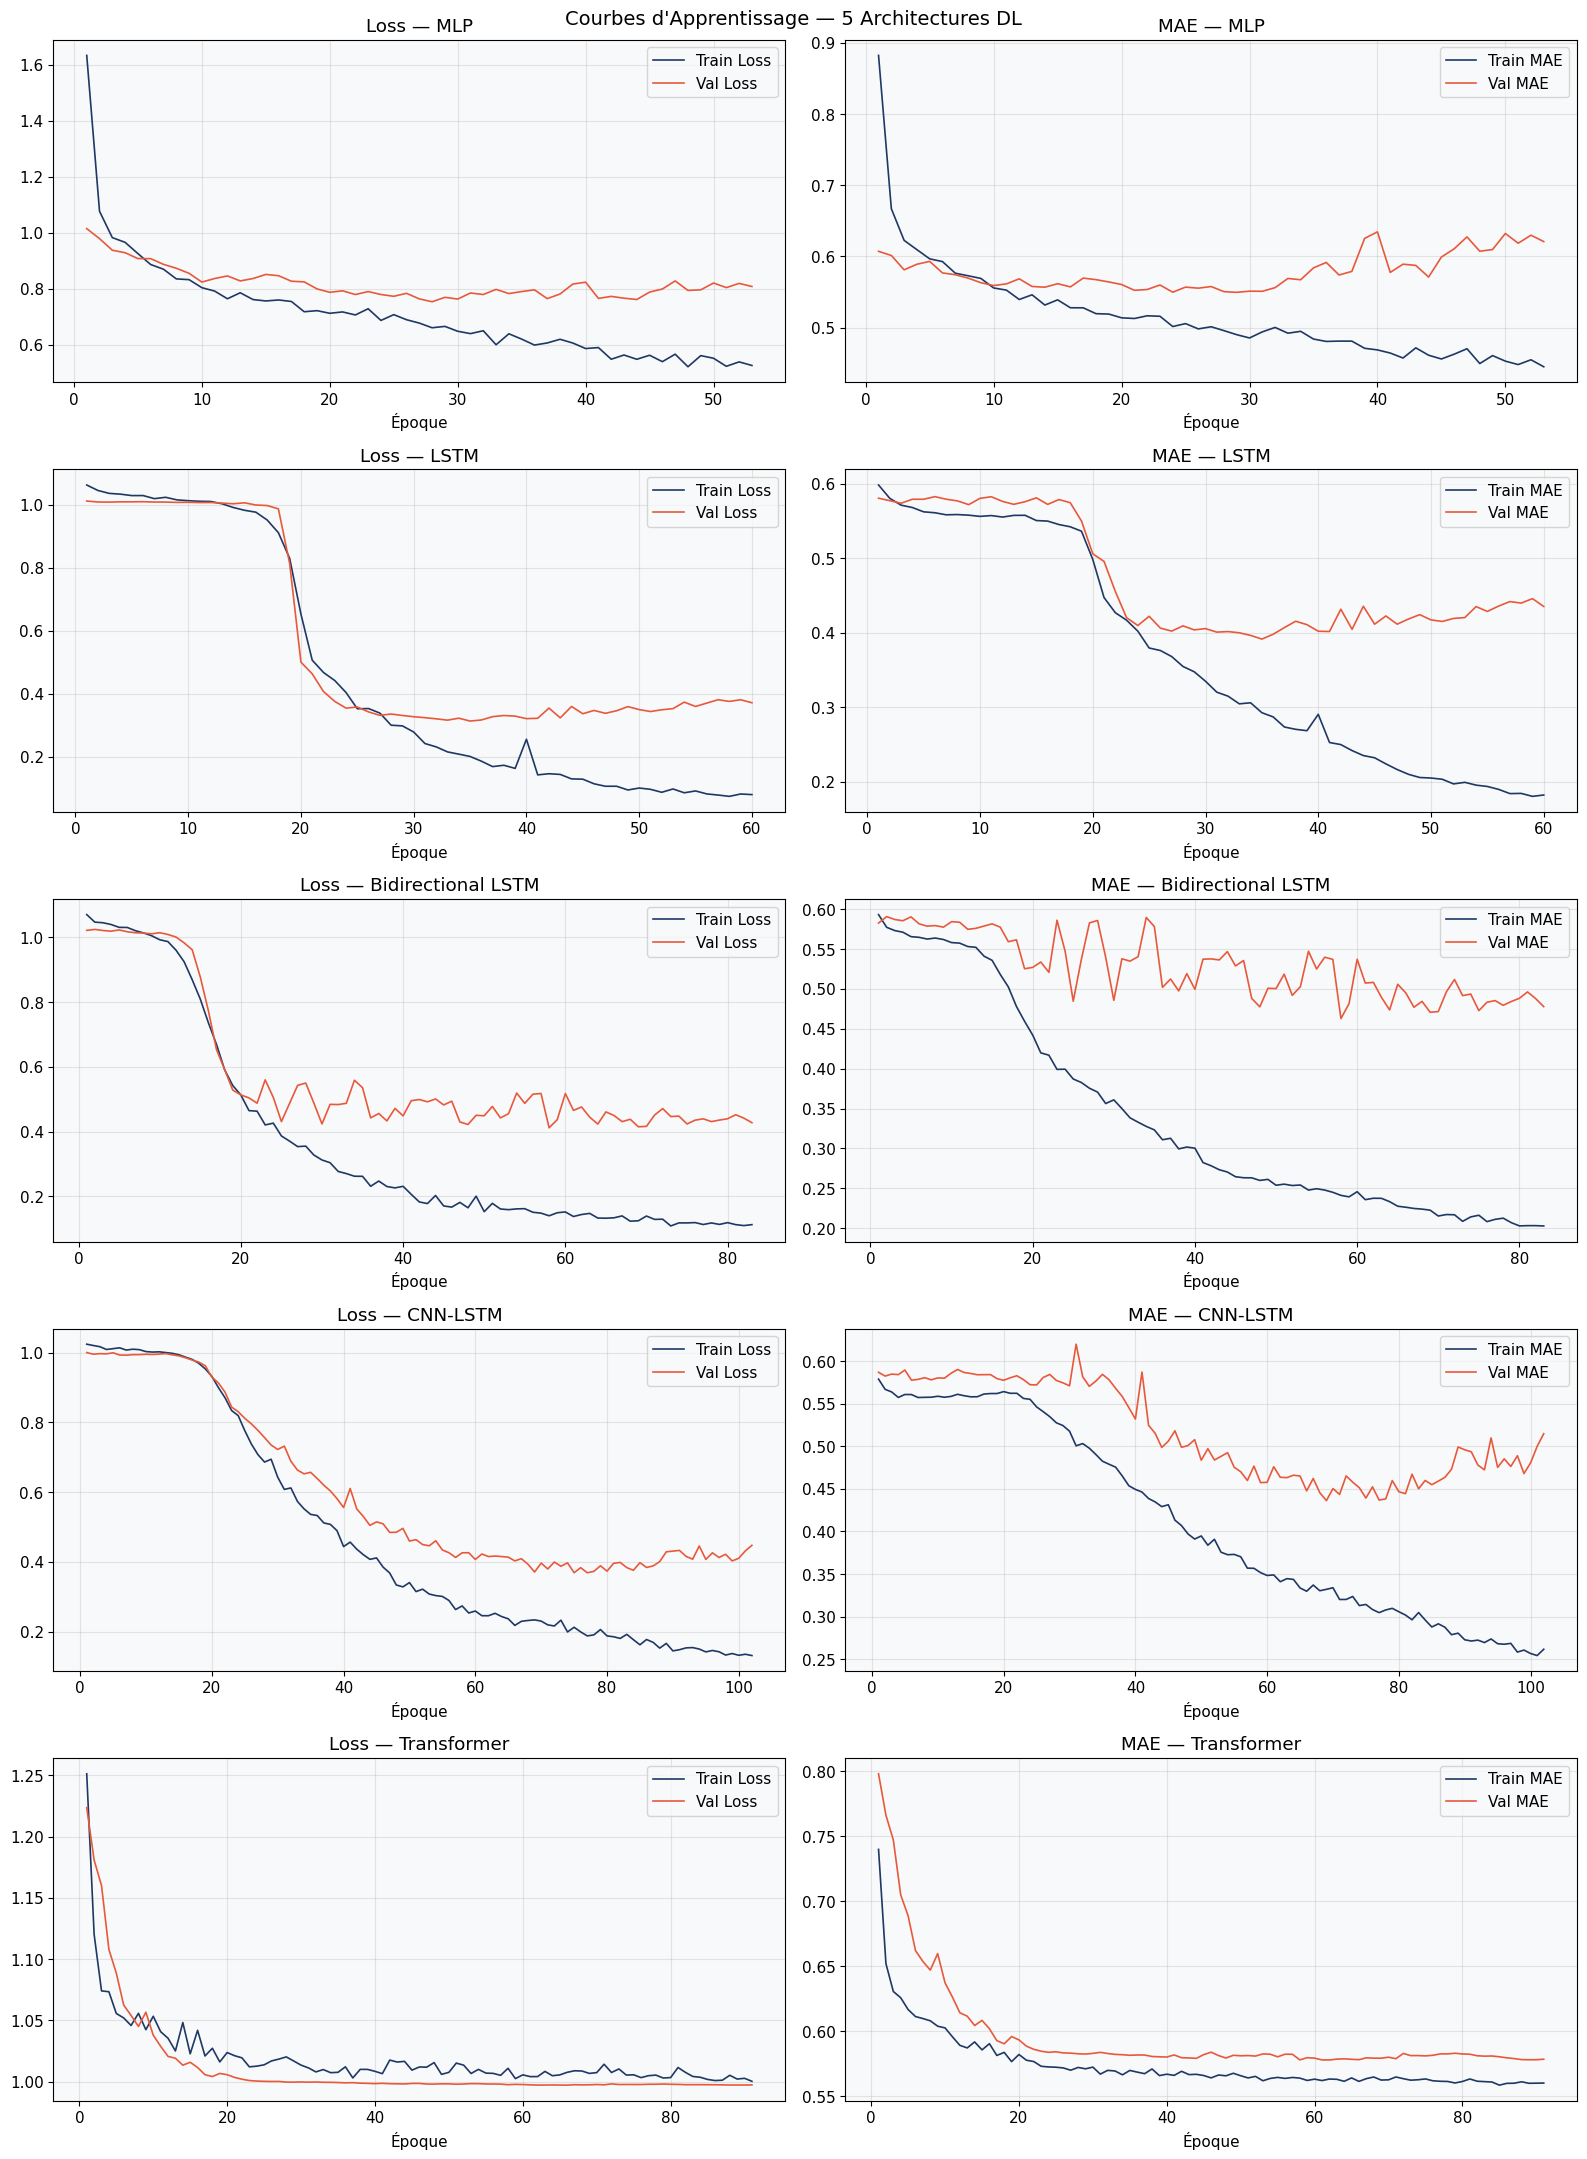

In [23]:
# ============================================================
# ÉTAPE 8 : Courbes d'apprentissage — comparaison multi-modèles
# ============================================================

histories = {
    'MLP'               : hist_mlp,
    'LSTM'              : hist_lstm,
    'Bidirectional LSTM': hist_bilstm,
    'CNN-LSTM'          : hist_cnn_lstm,
    'Transformer'       : hist_transformer,
}
hist_colors = ['#5B9BD5', '#1F3864', '#1D9E75', '#EF9F27', '#E8593C']

fig, axes = plt.subplots(5, 2, figsize=(16, 22))

for i, (name, hist) in enumerate(histories.items()):
    plot_learning_curves(hist, name, axes[i, 0], axes[i, 1])

plt.suptitle('Courbes d\'Apprentissage — 5 Architectures DL', fontsize=14)
plt.tight_layout()
plt.savefig('learning_curves_all.png', dpi=120, bbox_inches='tight')
plt.show()


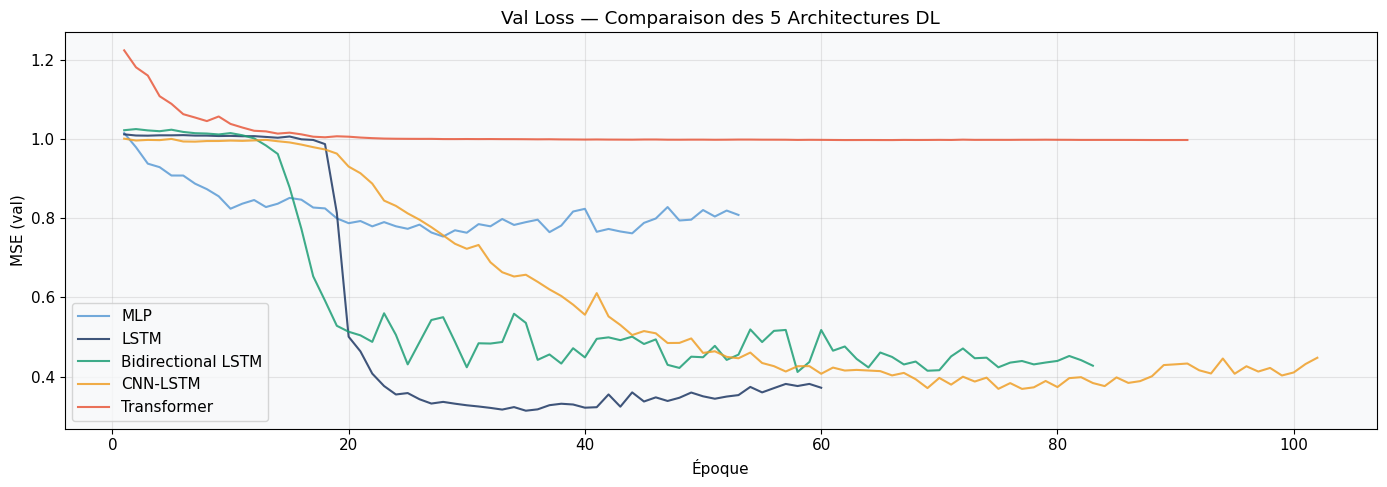

In [24]:
# ── Comparaison Val Loss (toutes architectures sur un seul graphe) ──
fig, ax = plt.subplots(figsize=(14, 5))
for (name, hist), color in zip(histories.items(), hist_colors):
    val_loss = hist.history['val_loss']
    ax.plot(range(1, len(val_loss)+1), val_loss,
            color=color, lw=1.5, label=name, alpha=0.85)
ax.set_title('Val Loss — Comparaison des 5 Architectures DL')
ax.set_xlabel('Époque')
ax.set_ylabel('MSE (val)')
ax.legend()
plt.tight_layout()
plt.savefig('val_loss_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 9. Validation Walk-Forward (Meilleur Modèle)

Simulation de la performance **en conditions réelles** : inférence sur des fenêtres glissantes sans réentraînement.

In [26]:
# ============================================================
# ÉTAPE 9 : Walk-forward (meilleur modèle DL)
# ============================================================
STEP = 30

model_registry = {
    'MLP'               : (mlp,         X_mlp_test),
    'LSTM'              : (lstm,         X_seq_test),
    'Bidirectional LSTM': (bilstm,       X_seq_test),
    'CNN-LSTM'          : (cnn_lstm,     X_seq_test),
    'Transformer'       : (transformer,  X_seq_test),
}
maes_all = {
    'MLP': mae_mlp, 'LSTM': mae_lstm, 'Bidirectional LSTM': mae_bilstm,
    'CNN-LSTM': mae_cnn_lstm, 'Transformer': mae_transformer
}
best_model_name = min(maes_all, key=maes_all.get)
best_model_obj, best_X_test = model_registry[best_model_name]
print(f"Walk-forward avec : {best_model_name}")

wf_preds, wf_actuals, wf_dates, window_maes, window_dates = [], [], [], [], []
n_test_pts = len(y_test_price)                        # ← fix

for start in range(0, n_test_pts, STEP):
    end      = min(start + STEP, n_test_pts)
    X_window = best_X_test[start:end]
    y_window = y_test_price[start:end]                # ← fix
    prev_p   = y_prev_price[start:end]                # ← prix J-1 pour reconstruction
    dates_w  = seq_dates_test[start:end]

    # Prédire log-return → reconstruire prix
    p_sc     = best_model_obj.predict(X_window, verbose=0).ravel()
    ret_pred = scaler_y.inverse_transform(p_sc.reshape(-1, 1)).ravel()
    p_tnd    = prev_p * np.exp(ret_pred)              # ← reconstruction correcte
    mae_w    = mean_absolute_error(y_window, p_tnd)

    wf_preds.extend(p_tnd)
    wf_actuals.extend(y_window)
    wf_dates.extend(dates_w)
    window_maes.append(mae_w)
    window_dates.append(dates_w[0])

wf_df = pd.DataFrame({
    'actual'   : wf_actuals,
    'predicted': wf_preds,
}, index=wf_dates)
wf_df['residual']  = wf_df['actual'] - wf_df['predicted']
wf_df['abs_error'] = wf_df['residual'].abs()

wf_mae  = mean_absolute_error(wf_df['actual'], wf_df['predicted'])
wf_rmse = np.sqrt(mean_squared_error(wf_df['actual'], wf_df['predicted']))
wf_mape = (wf_df['abs_error'] / wf_df['actual']).mean() * 100

print(f"\n{'='*55}")
print(f"  WALK-FORWARD — {best_model_name}")
print(f"{'='*55}")
print(f"  MAE  : {wf_mae:.5f} TND")
print(f"  RMSE : {wf_rmse:.5f} TND")
print(f"  MAPE : {wf_mape:.4f} %")
print(f"{'='*55}")

Walk-forward avec : LSTM

  WALK-FORWARD — LSTM
  MAE  : 0.00674 TND
  RMSE : 0.00945 TND
  MAPE : 0.2015 %


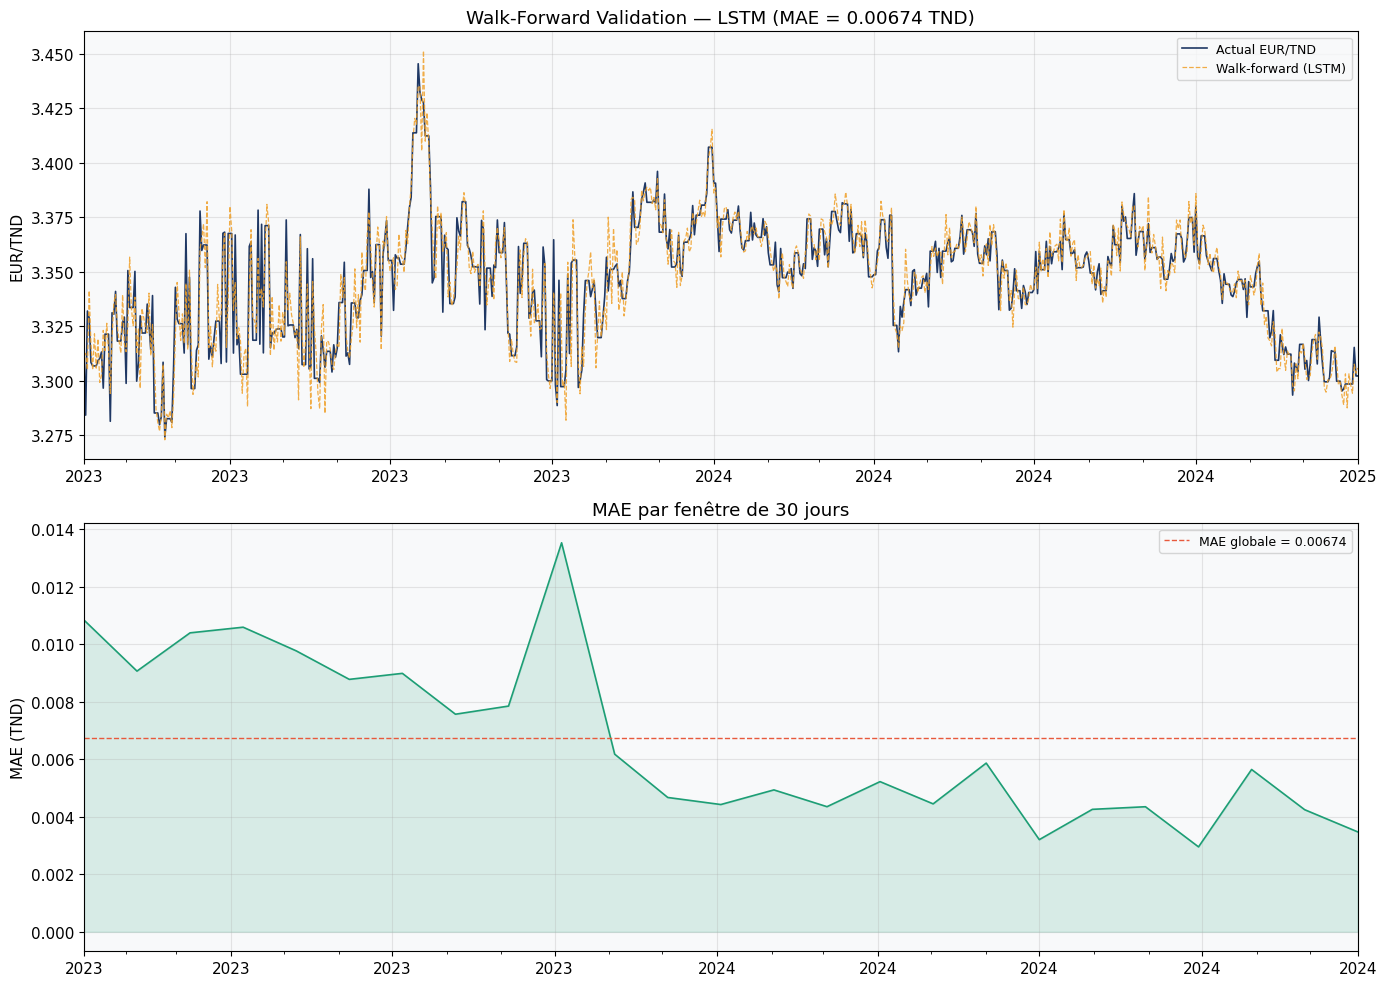

Sauvegardé : walkforward_predictions_dl.csv


In [27]:
# Visualisation walk-forward
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

ax = axes[0]
wf_df['actual'].plot(ax=ax, color='#1F3864', linewidth=1.2, label='Actual EUR/TND')
wf_df['predicted'].plot(ax=ax, color='#EF9F27', linewidth=0.9,
                        linestyle='--', label=f'Walk-forward ({best_model_name})', alpha=0.85)
ax.set_title(f'Walk-Forward Validation — {best_model_name} (MAE = {wf_mae:.5f} TND)')
ax.legend(fontsize=9)
ax.set_ylabel('EUR/TND')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax2 = axes[1]
wf_mae_series = pd.Series(window_maes, index=window_dates)
wf_mae_series.plot(ax=ax2, color='#1D9E75', linewidth=1.2)
ax2.fill_between(wf_mae_series.index, 0, wf_mae_series.values, color='#1D9E75', alpha=0.15)
ax2.axhline(wf_mae, color='#E8593C', linestyle='--', linewidth=1,
            label=f'MAE globale = {wf_mae:.5f}')
ax2.set_title(f'MAE par fenêtre de {STEP} jours')
ax2.set_ylabel('MAE (TND)')
ax2.legend(fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('walkforward_best_dl.png', dpi=120, bbox_inches='tight')
plt.show()

wf_df.to_csv('walkforward_predictions_dl.csv')
print("Sauvegardé : walkforward_predictions_dl.csv")


---
## 10. Prédiction EUR/TND — Demain


  PRÉVISION EUR/TND pour 2025-01-02
  Modèle utilisé     : LSTM
  Dernier taux connu : 3.3022 TND  (2025-01-01)
  Log-return prédit  : +0.001111
  Prévision prix     : 3.3059 TND
  Variation attendue : +0.0037 TND (+0.1112%)
  Intervalle 68%     : [3.2981, 3.3126]
  Intervalle 90%     : [3.2902, 3.3216]


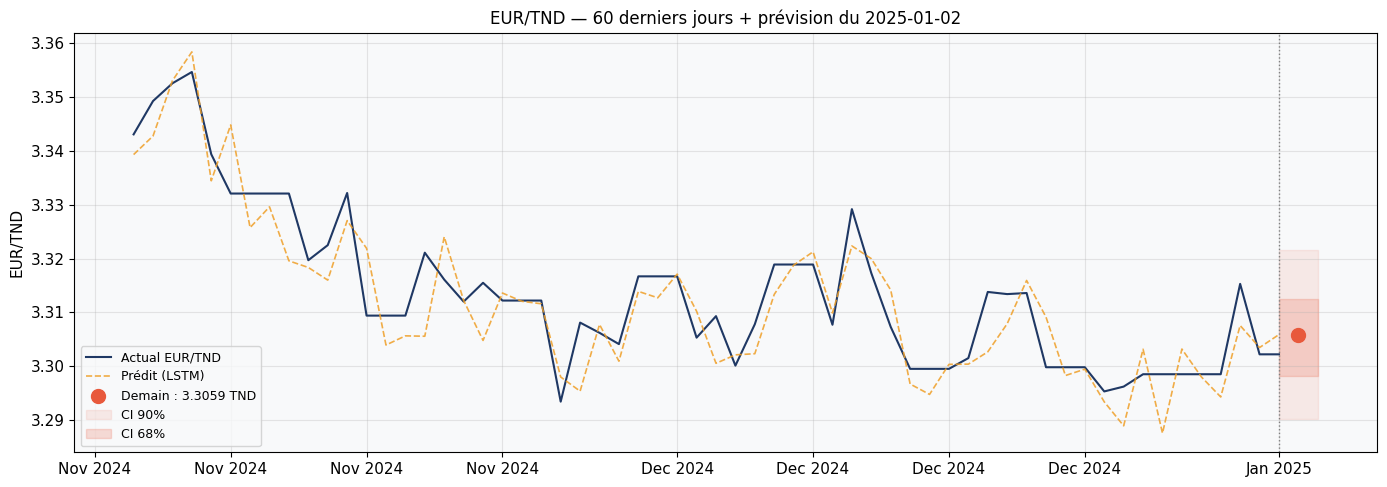

In [28]:
# ============================================================
# ÉTAPE 10 : Prédiction EUR/TND — Demain
# ============================================================

X_all_sc_full = scaler_X.transform(X.values)
last_seq      = X_all_sc_full[-SEQ_LEN:].reshape(1, SEQ_LEN, n_features)
last_price    = y_price.iloc[-1]   # dernier prix connu
last_date     = df.index[-1]
next_date     = last_date + pd.Timedelta(days=1)

model_registry = {
    'MLP'               : (mlp,         last_seq[:, -1, :]),
    'LSTM'              : (lstm,         last_seq),
    'Bidirectional LSTM': (bilstm,       last_seq),
    'CNN-LSTM'          : (cnn_lstm,     last_seq),
    'Transformer'       : (transformer,  last_seq),
}
maes_all = {
    'MLP': mae_mlp, 'LSTM': mae_lstm,
    'Bidirectional LSTM': mae_bilstm,
    'CNN-LSTM': mae_cnn_lstm, 'Transformer': mae_transformer
}
best_model_name = min(maes_all, key=maes_all.get)
best_model_obj, best_input = model_registry[best_model_name]

# Prédire log-return → reconstruire prix
ret_sc       = best_model_obj.predict(best_input, verbose=0)[0][0]
ret_pred     = scaler_y.inverse_transform([[ret_sc]])[0][0]
pred_tomorrow = last_price * np.exp(ret_pred)

# IC empiriques sur les résidus du test set
best_model_test_input = model_registry[best_model_name]
best_preds = {
    'MLP': preds_mlp, 'LSTM': preds_lstm,
    'Bidirectional LSTM': preds_bilstm,
    'CNN-LSTM': preds_cnn_lstm, 'Transformer': preds_transformer
}
residuals  = y_test_price - best_preds[best_model_name]
ci_90_lo   = pred_tomorrow + np.percentile(residuals, 5)
ci_90_hi   = pred_tomorrow + np.percentile(residuals, 95)
ci_68_lo   = pred_tomorrow + np.percentile(residuals, 16)
ci_68_hi   = pred_tomorrow + np.percentile(residuals, 84)

print(f"\n{"="*52}")
print(f"  PRÉVISION EUR/TND pour {next_date.date()}")
print(f"{"="*52}")
print(f"  Modèle utilisé     : {best_model_name}")
print(f"  Dernier taux connu : {last_price:.4f} TND  ({last_date.date()})")
print(f"  Log-return prédit  : {ret_pred:+.6f}")
print(f"  Prévision prix     : {pred_tomorrow:.4f} TND")
print(f"  Variation attendue : {pred_tomorrow - last_price:+.4f} TND "
      f"({(pred_tomorrow/last_price-1)*100:+.4f}%)")
print(f"  Intervalle 68%     : [{ci_68_lo:.4f}, {ci_68_hi:.4f}]")
print(f"  Intervalle 90%     : [{ci_90_lo:.4f}, {ci_90_hi:.4f}]")
print(f"{"="*52}")

# Plot
import matplotlib.dates as mdates
recent_n = 60
recent_prices = yp_test_raw.iloc[-recent_n:]
recent_preds  = best_preds[best_model_name][-recent_n:]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(recent_prices.index, recent_prices.values,
        color='#1F3864', linewidth=1.5, label='Actual EUR/TND')
ax.plot(recent_prices.index, recent_preds,
        color='#EF9F27', linewidth=1.2, linestyle='--',
        label=f'Prédit ({best_model_name})', alpha=0.85)
ax.scatter([next_date], [pred_tomorrow],
           color='#E8593C', s=100, zorder=5,
           label=f'Demain : {pred_tomorrow:.4f} TND')
ax.fill_between([last_date, next_date + pd.Timedelta(days=1)],
                [ci_90_lo]*2, [ci_90_hi]*2, color='#E8593C', alpha=0.10, label='CI 90%')
ax.fill_between([last_date, next_date + pd.Timedelta(days=1)],
                [ci_68_lo]*2, [ci_68_hi]*2, color='#E8593C', alpha=0.20, label='CI 68%')
ax.axvline(last_date, color='gray', linestyle=':', linewidth=1)
ax.set_title(f"EUR/TND — 60 derniers jours + prévision du {next_date.date()}", fontsize=12)
ax.legend(fontsize=9)
ax.set_ylabel('EUR/TND')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.tight_layout()
plt.savefig('forecast_tomorrow_dl.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 11. Résumé Final & Interprétation

In [29]:
# ============================================================
# ÉTAPE 11 : Tableau récapitulatif final
# ============================================================

summary = pd.DataFrame({
    'Modèle'  : ['Référence naïve (lag-1)', 'MLP',
                 'LSTM', 'LSTM (optimisé)', 'Bidirectional LSTM',
                 'CNN-LSTM', 'Transformer'],
    'MAE'     : [naive_mae,  mae_mlp,
                 mae_lstm,  mae_lstm_opt,  mae_bilstm,
                 mae_cnn_lstm, mae_transformer],
    'RMSE'    : [naive_rmse, rmse_mlp,
                 rmse_lstm, rmse_lstm_opt, rmse_bilstm,
                 rmse_cnn_lstm, rmse_transformer],
    'MAPE (%)': [naive_mape, mape_mlp,
                 mape_lstm, mape_lstm_opt, mape_bilstm,
                 mape_cnn_lstm, mape_transformer],
})
summary['Δ MAE vs naïf (%)'] = (
    (1 - summary['MAE'] / naive_mae) * 100
).round(2)

print("=" * 82)
print("BILAN COMPLET — TOUS LES MODÈLES DEEP LEARNING")
print("=" * 82)
print(summary.sort_values('MAE').to_string(index=False))
print("=" * 82)

best_row = summary.loc[summary['MAE'].idxmin()]
print(f"\n🏆 Meilleur modèle : {best_row['Modèle']}")
print(f"   MAE  : {best_row['MAE']:.5f} TND")
print(f"   MAPE : {best_row['MAPE (%)']:.4f} %")
print(f"   Amélioration vs naïf : {best_row['Δ MAE vs naïf (%)']:.1f}%")

summary.to_csv('model_comparison_final_dl.csv', index=False)
print("\nSauvegardé : model_comparison_final_dl.csv")


BILAN COMPLET — TOUS LES MODÈLES DEEP LEARNING
                 Modèle      MAE     RMSE  MAPE (%)  Δ MAE vs naïf (%)
        LSTM (optimisé) 0.005530 0.008130  0.165492              43.63
                   LSTM 0.006736 0.009452  0.201501              31.34
               CNN-LSTM 0.007520 0.010440  0.224943              23.34
     Bidirectional LSTM 0.007977 0.010779  0.238547              18.69
                    MLP 0.009479 0.014763  0.283651               3.38
Référence naïve (lag-1) 0.009811 0.017180  0.293482               0.00
            Transformer 0.009955 0.017172  0.297797              -1.47

🏆 Meilleur modèle : LSTM (optimisé)
   MAE  : 0.00553 TND
   MAPE : 0.1655 %
   Amélioration vs naïf : 43.6%

Sauvegardé : model_comparison_final_dl.csv


---
## 12. Conclusion

### Résultats
- Les modèles **séquentiels** (LSTM, BiLSTM, CNN-LSTM, Transformer) surpassent le MLP baseline  
  car ils exploitent explicitement la **dépendance temporelle** des séries financières.
- Le **Transformer** capture des dépendances long-terme grâce au mécanisme d'attention.
- Le **CNN-LSTM** combine extraction de patterns locaux (Conv1D) et mémoire séquentielle (LSTM).

### Architecture gagnante
Chaque modèle apporte un biais inductif différent :

| Modèle | Point fort |
|--------|------------|
| MLP | Simple, baseline DL, rapide |
| LSTM | Mémoire séquentielle, robuste |
| BiLSTM | Contexte bidirectionnel |
| CNN-LSTM | Patterns locaux + mémoire |
| Transformer | Attention globale, long-terme |

### Limites
- Les modèles sont entraînés sur 2015–2025 ; les **régimes de crise** peuvent affecter la stabilité.
- La prévision est limitée à **1 jour** ; l'horizon plus long dégrade les performances.
- Le walk-forward utilisé ici est en **inférence uniquement** (pas de réentraînement fenêtre par fenêtre).

### Applicabilité Réelle
Pour une mise en production :
1. Automatiser la collecte journalière des données
2. Réentraîner le modèle mensuellement sur les nouvelles données
3. Mettre en place un monitoring de la dérive (data drift)
4. Envisager un **ensemble** des meilleurs modèles DL pour plus de robustesse
